In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


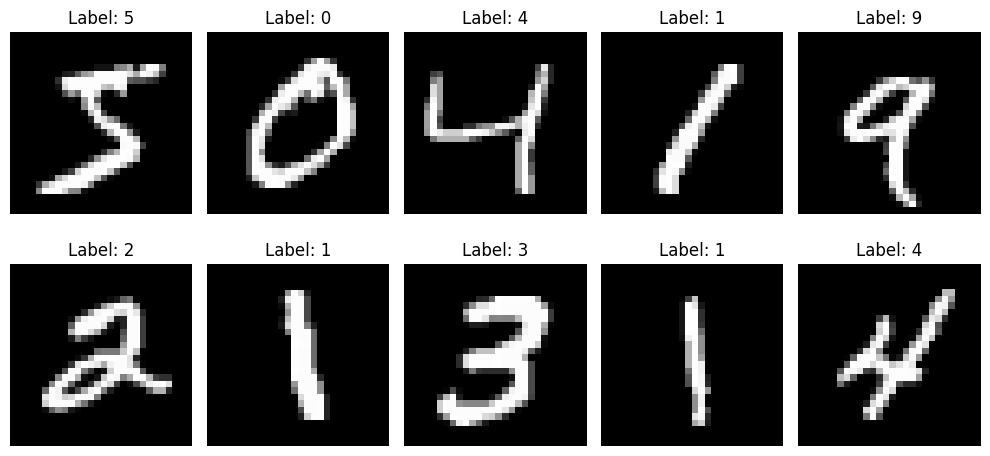

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Minimum: 0.0
Maximum: 1.0


In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [7]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [8]:
model = models.Sequential([
    
    # Input layer
    layers.Input(shape=(28, 28, 1)),
    
    # First Convolution Layer
    layers.Conv2D(32, (3, 3), activation="relu"),
    
    # Pooling
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolution Layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    
    # Pooling
    layers.MaxPooling2D((2, 2)),
    
    # Flatten
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(128, activation="relu"),
    
    # Output Layer
    layers.Dense(10, activation="softmax")
])

model.summary()

2026-08-31 05:33:50.716782: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9319 - loss: 0.2289 - val_accuracy: 0.9815 - val_loss: 0.0653
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9816 - loss: 0.0597 - val_accuracy: 0.9842 - val_loss: 0.0530
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9866 - loss: 0.0413 - val_accuracy: 0.9882 - val_loss: 0.0403
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9897 - loss: 0.0320 - val_accuracy: 0.9912 - val_loss: 0.0346
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9903 - val_loss: 0.0331
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9939 - loss: 0.0192 - val_accuracy: 0.9918 - val_loss: 0.0355
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9948 - loss: 0.0164 - val_accuracy: 0.9917 - val_loss: 0.0328
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9959 - loss: 0.0133 - 

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.02986624464392662
Test Accuracy: 0.9912999868392944


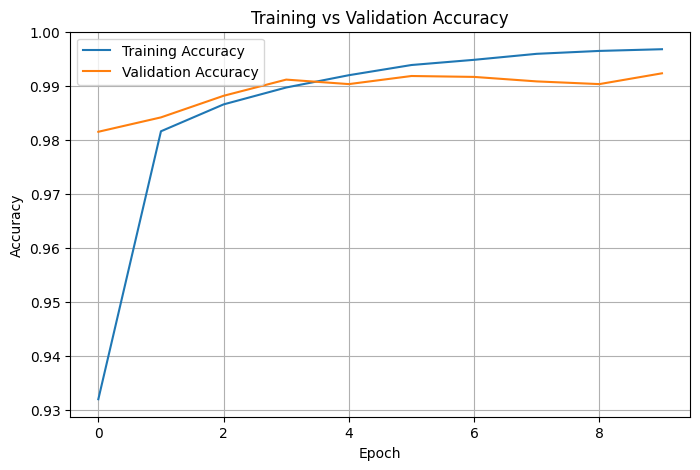

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

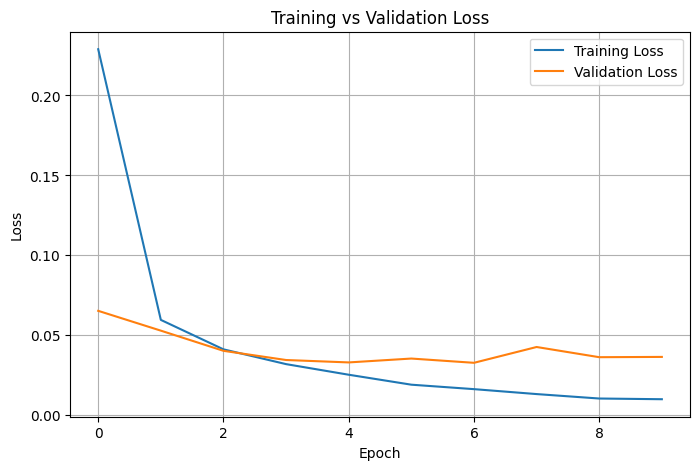

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [14]:
predictions = model.predict(X_test)

print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
(10000, 10)


In [15]:
predicted_labels = np.argmax(predictions, axis=1)

actual_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:   ", actual_labels[:10])

Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


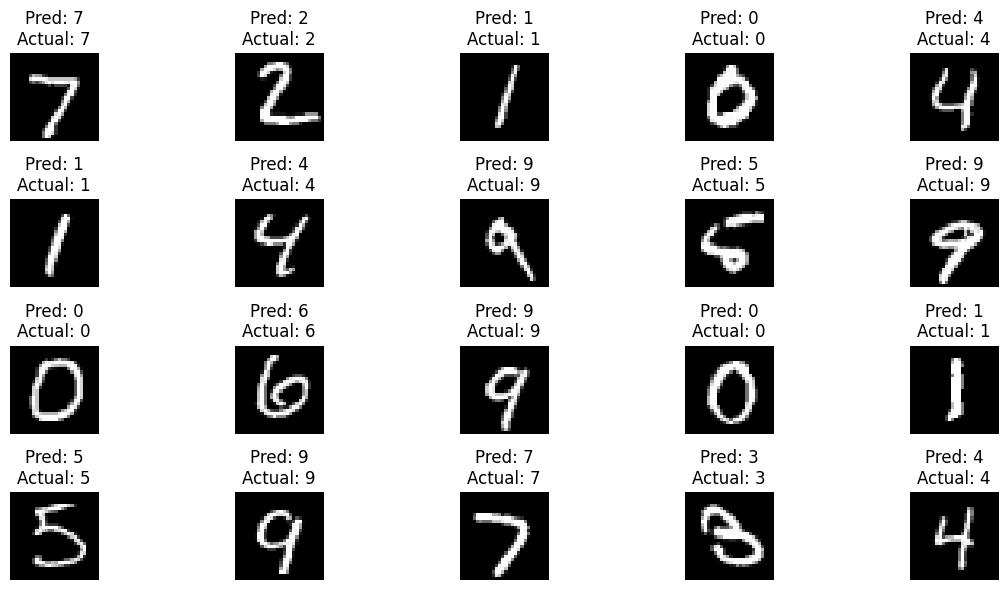

In [16]:
plt.figure(figsize=(12, 6))

for i in range(20):
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    
    plt.title(
        f"Pred: {predicted_labels[i]}\n"
        f"Actual: {actual_labels[i]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
incorrect = np.where(predicted_labels != actual_labels)[0]

print("Total incorrect predictions:", len(incorrect))

Total incorrect predictions: 87


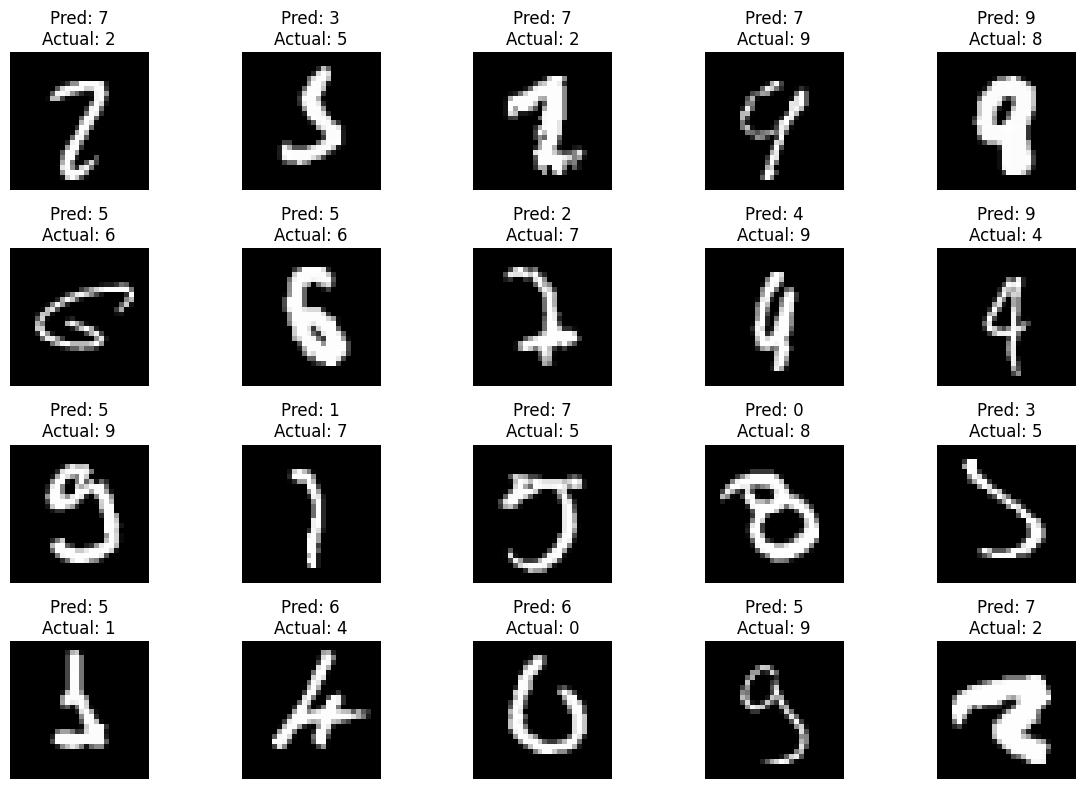

In [18]:
plt.figure(figsize=(12, 8))

for i in range(min(20, len(incorrect))):
    
    index = incorrect[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )
    
    plt.title(
        f"Pred: {predicted_labels[index]}\n"
        f"Actual: {actual_labels[index]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

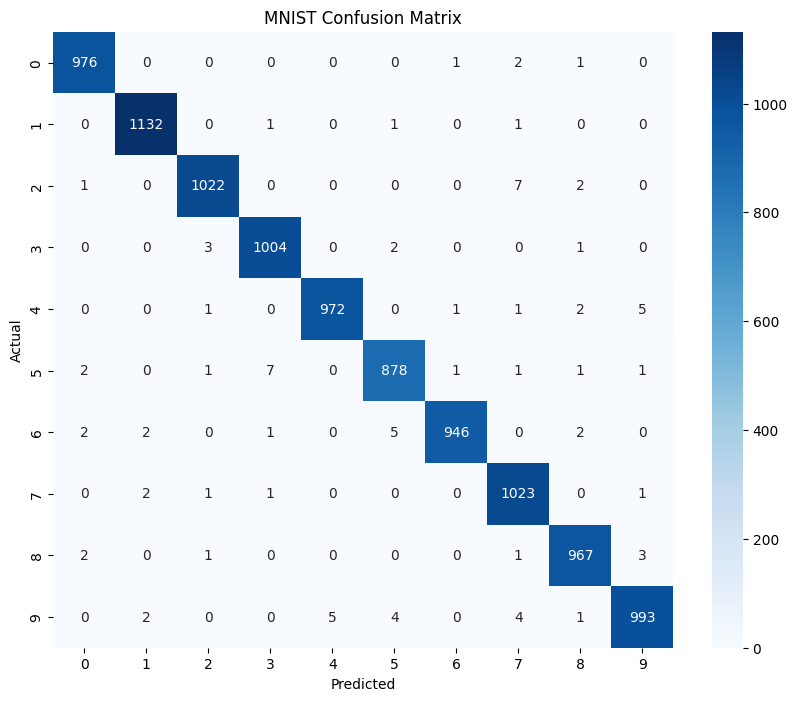

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [21]:
model.save("handwritten_digit_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [22]:
loaded_model = tf.keras.models.load_model(
    "handwritten_digit_cnn.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


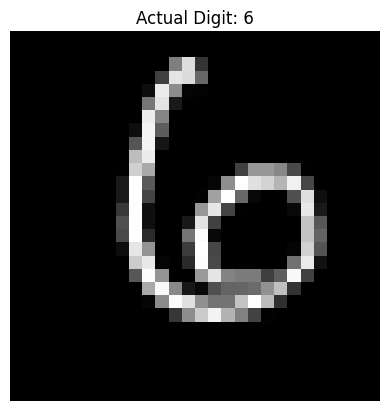

In [23]:
index = 100

image = X_test[index]

plt.imshow(
    image.reshape(28, 28),
    cmap="gray"
)

plt.title(f"Actual Digit: {actual_labels[index]}")
plt.axis("off")
plt.show()

In [24]:
image_input = np.expand_dims(image, axis=0)
prediction = loaded_model.predict(image_input)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100
print("Predicted Digit:", predicted_digit)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted Digit: 6
Confidence: 100.0 %


In [25]:
def predict_digit(image):
    
    # Normalize
    image = image.astype("float32") / 255.0
    
    # Reshape
    image = image.reshape(1, 28, 28, 1)
    
    # Prediction
    prediction = loaded_model.predict(image, verbose=0)
    
    # Get digit
    digit = np.argmax(prediction)
    
    # Confidence
    confidence = np.max(prediction) * 100
    return digit, confidence

In [26]:
digit, confidence = predict_digit(
    X_test[50].reshape(28, 28) * 255
)

print("Predicted Digit:", digit)
print("Confidence:", round(confidence, 2), "%")

Predicted Digit: 6
Confidence: 100.0 %
